all cuts 656
all cuts 35
3cuts: 12
[[0], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]]
[[0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], [1]]
[[0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11], [2]]
[[0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11], [3]]
[[0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11], [4]]
[[0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11], [5]]
[[0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11], [6]]
[[0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11], [7]]
[[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11], [8]]
[[0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11], [9]]
[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11], [10]]
[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [11]]
4cuts: 23
[[0, 11], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]]
[[0, 6], [1, 2, 3, 4, 5, 7, 8, 9, 10, 11]]
[[0, 2, 3, 4, 6, 7, 8, 9, 10, 11], [1, 5]]
[[0, 3, 4, 5, 6, 7, 8, 9, 10, 11], [1, 2]]
[[0, 1], [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]]
[[0, 1, 5, 6], [2, 3, 4, 7, 8, 9, 10, 11]]
[[0, 1, 4, 5, 6, 7, 8, 9, 10, 11], [2, 3]]
[[0, 1, 3, 4, 5, 6, 7, 8, 9, 10], [2, 11]]
[[0, 1, 2, 11], [3, 4, 5, 6, 7, 8, 9, 10]]
[[0, 1, 2, 5, 6, 11], [3, 4, 7, 8, 9, 10]]
[[0, 1, 2

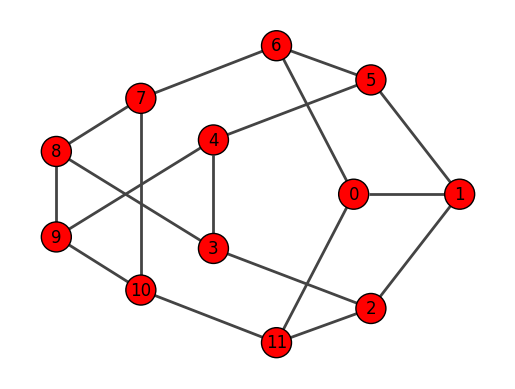

In [2]:
import igraph as ig
import matplotlib.pyplot as plt


#numvertices = 8
#g = ig.Graph(n=numvertices, edges=[[0, 1], [0, 2], [0, 5], [1, 2], [1, 3], [2, 3], [2, 4], [3, 4], [3, 7], [4, 5], [4, 6], [4, 7], [5, 6], [6, 7]])
#numvertices = 12
#g = ig.Graph(n=numvertices, edges=[[0, 1], [0, 11], [0, 9], [1, 2], [1, 4], [2, 3], [2, 11], [3, 4], [3, 6], [4, 5], [5, 6], [5, 8], [6, 7], [7, 8], [7, 10], [8, 9], [9, 10], [10, 11]])
#numvertices = 6
#g = ig.Graph(n=numvertices, edges=[[0, 1], [0, 3], [0, 5], [1, 2], [1, 4], [2, 3], [2, 5], [3, 4], [4, 5]])
#numvertices = 8
#g = ig.Graph(n=numvertices, edges=[[0, 1], [1, 2], [2, 3], [3, 4], [4, 5], [5, 6], [6, 7], [7, 0], [0, 4], [1, 5], [2, 6], [3, 7]])

#make a cycle
edges = []
numvertices = 12
for num in range(numvertices):
    edges.append([num, (num+1) % numvertices])

bonusedges = [[0,6], [1,5], [2,11], [3,8], [4,9] , [7,10]]
edges = edges + bonusedges
g = ig.Graph(n=numvertices, edges=edges)


fig, ax = plt.subplots()
#ig.plot(g, target=ax, 
#        vertex_label=['0', '1', '2', '3', '4', '5', '6', '7'],)
ig.plot(g, target=ax, 
        vertex_label=['0', '1', '2', '3', '4', '5', '6', '7','8','9','10','11'],)
#ax.invert_yaxis()

g = g.as_directed()
#all st cuts, the function used to get all the cuts, only works with directed graphs, even though the result is the same as an undirected graph


allcuts = []
i = 0
while i < numvertices:
    j = i+1
    while j < numvertices:
        cuts = g.all_st_cuts(i, j)

        #filter out the cuts that aren't 3 or 4 cuts
        for specificcut in cuts[:]:
            if ((specificcut.value == 3) or (specificcut.value == 4)):
                continue
            else:
                cuts.remove(specificcut)
        allcuts = allcuts + cuts

        j = j+1
    i = i+1

#remove duplicates
print("all cuts", len(allcuts))
allcutlen = len(allcuts)
i = 0
while i < allcutlen:
    j = i+1
    while j < allcutlen:
        if(allcuts[i].partition[1] == allcuts[j].partition[1] or allcuts[i].partition[0] == allcuts[j].partition[1]):
            allcuts.pop(j)
            allcutlen = allcutlen - 1
            j = j-1            
        j = j+1
    i = i+1
print("all cuts", len(allcuts))

threecuts = []
fourcuts = []

for somecut in allcuts:
    #print(somecut.partition)
    #print(somecut)
    if (somecut.value == 3):
        threecuts.append(somecut)
    else:
        fourcuts.append(somecut)

print("3cuts:", len(threecuts))
for somecut in threecuts:
    print(somecut.partition)
    #print(somecut)
print("4cuts:", len(fourcuts))
for somecut in fourcuts:
    print(somecut.partition)
    #print(somecut)


#for specificcut in cuts:
#    if ((specificcut.value == 3) or (specificcut.value == 4)):
#        print(specificcut)
#        fig, ax = plt.subplots()
#        ig.plot(specificcut, target=ax,vertex_label=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h'])
#        ax.invert_yaxis()
#        plt.figure()
#    #index = index +1


In [2]:
edges = []
numvertices = 12
for num in range(numvertices):
    edges.append([num, (num+1) % numvertices])
print(edges)

[[0, 1], [1, 2], [2, 3], [3, 4], [4, 5], [5, 6], [6, 7], [7, 8], [8, 9], [9, 10], [10, 11], [11, 0]]


((0, 8), (0, 9), (1, 3), (4, 1), (6, 4), (6, 5), (6, 7), (9, 2), (9, 6)) 4


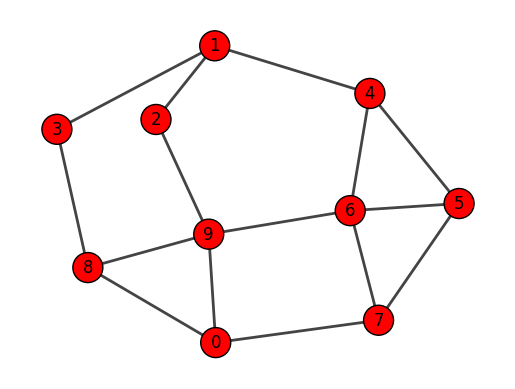

In [15]:
import numpy as np



def spanningTreeCongestion(graph, spanningTree) -> int:
    'the spanning tree MUST be valid, little error checking is done to ensure it is valid. graph is the undirected base igraph object of the graph in question. st edge is a list of tuples (or whatever the parentheses are) representing the edges in the spanning tree. corresponding vertices must be named the same on both graphs, 0 to n-1'

    maxCongestion = 1
    STedges = spanningTree.get_edgelist()

    #these are needed beacuse all_st_cuts does not work with an undirected graph, and was the easiest way for me to create a partition given the spanning tree (i don't need to personally figure out which edge is where)
    directedSpanningTree = spanningTree.as_directed()

    for edge in STedges:
        treeCuts = directedSpanningTree.all_st_cuts(edge[0], edge[1])

        if (len(treeCuts) != 1):
            print("WEEWOO")
            raise Exception("given cut of spanning tree does not have one edge")
        
        leftpart = treeCuts[0].partition[0]
        rightpart = treeCuts[0].partition[1]
        edgeCongestion = 0

        #for every combination of left part-right part, check if there is an edge in the original graph, if so that adds 1 to the congestion
        #the spanning tree edge will be counted as well with this method
        for leftvertex in leftpart:
            for rightvertex in rightpart:
                #the matrix form of the graph that igraph gives has numbers represent the weights as well, allowing us to account for multigraphs
                edgeCongestion += graph[leftvertex, rightvertex]
        
        if (edgeCongestion > maxCongestion):
            maxCongestion = edgeCongestion

    return maxCongestion

#gives a list of tuples of edges, each tuple is a spanning tree and containes edges represented by tuples
def getAllSpanningTrees(graph) -> list[tuple[int, int]]:
    'gives a list of tuples of edges, each tuple is a spanning tree and containes edges represented by tuples'
    spanningtrees = []
    adjmatrix = np.array(graph.get_adjacency())
    currTree = ()
    currVertices = (0,)
    getSpanningTreeRecursive(adjmatrix, currTree, currVertices, spanningtrees)

    return spanningtrees


def getSpanningTreeRecursive(adjacency, currTreeEdges, currTreeVertices, spanningTreeList):
    n = adjacency.shape[1]
    if (len(currTreeEdges) == n-1):
        currTreeEdges = tuple(sorted(currTreeEdges))
        if currTreeEdges not in spanningTreeList:
            spanningTreeList.append(currTreeEdges)
        return
    for vertex in currTreeVertices:
        for i in range(n):
            if i in currTreeVertices:
                continue
            if (adjacency[vertex][i]):
                getSpanningTreeRecursive(adjacency, currTreeEdges + ((vertex, i),), currTreeVertices + (i,), spanningTreeList) 
    return

#sanity check, use kirchoff's theorem to figure out how many spanning trees there should be
def getNumSpanningTrees(graph) -> int:
    'use kirchoffs theorem to figure out how many spanning trees there should be'
    adjmatrix = np.array(graph.get_adjacency())
    adjmatrix = -1 * adjmatrix

    for i in range(adjmatrix.shape[1]):
        adjmatrix[i][i] = 0
        for j in range(adjmatrix.shape[1]):
            if adjmatrix[i][j] == -1:
                adjmatrix[i][i]  += 1
    adjmatrix = np.delete(adjmatrix, 0, axis=0)
    adjmatrix = np.delete(adjmatrix, 0, axis=1)

    return round(np.linalg.det(adjmatrix))


def getMinimumCongestionSpanningTrees(graph) -> tuple[list[list[tuple[int, int]]], int]:
    'tuple is ([list of min span trees in edges], congestion)'
    minSpanTrees = []
    allSpanTrees = getAllSpanningTrees(graph)
    if (len(allSpanTrees) != getNumSpanningTrees(graph)):
        raise Exception("Number of spanning trees does not match how many should exist")
    congestions = []
    for spanningtreeedgeset in allSpanTrees:
        congestions.append(spanningTreeCongestion(graph, ig.Graph(edges=spanningtreeedgeset)))
    minCongestion = min(congestions)
    for i in range(len(allSpanTrees)):
        if (congestions[i] == minCongestion):
            minSpanTrees.append(allSpanTrees[i])
    return minSpanTrees, minCongestion

def getMinSTCIncludeExlcude(graph, includeEdges, excludeEdges) -> tuple[list[list[tuple[int, int]]], int]:
    'included edges sohuld be a list of some kind of iterable. same with exclude edges. returns an empty list  and -1 congestion if none found'
    minSpanTrees = []
    allSpanTrees = getAllSpanningTrees(graph)
    if (len(allSpanTrees) != getNumSpanningTrees(graph)):
        raise Exception("Number of spanning trees does not match how many should exist")
    viableSpanTrees = []

    for spanningtree in allSpanTrees:
        #this is messy but not the part thats slow so its ok
        viabletree = True
        for edge in includeEdges:
            if (edge[0], edge[1]) not in spanningtree and (edge[1], edge[0]) not in spanningtree:
                viabletree = False
        for edge in excludeEdges:
            if (edge[0], edge[1]) in spanningtree or (edge[1], edge[0]) in spanningtree:
                viabletree = False
        if viabletree:
            viableSpanTrees.append(spanningtree)
    if not viableSpanTrees:
        #this shouldnt happen unless the include/exclude itself is impossible (excludes all edges connecting a vertex, for example). returns -2 so you know something went wrong-er
        return [], -2
    congestions = []
    for spanningtreeedgeset in viableSpanTrees:
        congestions.append(spanningTreeCongestion(graph, ig.Graph(edges=spanningtreeedgeset)))
    minCongestion = min(congestions)
    for i in range(len(viableSpanTrees)):
        if (congestions[i] == minCongestion):
            minSpanTrees.append(viableSpanTrees[i])
    return minSpanTrees, minCongestion

def getSTCIncludeExlcude(graph, includeEdges, excludeEdges, targetCongestion) -> tuple[list[tuple[int, int]], int]:
    'returns a spanning tree with **less than or equal** congestion, as well as the congestion, that satisfies the include/exclude. can send in empty sets if you only want to test for possible congestion. '
    allSpanTrees = getAllSpanningTrees(graph)
    if (len(allSpanTrees) != getNumSpanningTrees(graph)):
        raise Exception("Number of spanning trees does not match how many should exist")
    viableSpanTrees = []

    for spanningtree in allSpanTrees:
        #this is messy but not the part thats slow so its ok
        viabletree = True
        for edge in includeEdges:
            if (edge[0], edge[1]) not in spanningtree and (edge[1], edge[0]) not in spanningtree:
                viabletree = False
        for edge in excludeEdges:
            if (edge[0], edge[1]) in spanningtree or (edge[1], edge[0]) in spanningtree:
                viabletree = False
        if viabletree:
            viableSpanTrees.append(spanningtree)
    if not viableSpanTrees:
        #this shouldnt happen unless the include/exclude itself is impossible (excludes all edges connecting a vertex, for example). returns -2 so you know something went wrong-er
        return [], -2
    
    currBest = []
    minCongestion = 9999
    for spanningtreeedgeset in viableSpanTrees:
        cong = spanningTreeCongestion(graph, ig.Graph(edges=spanningtreeedgeset))
        if cong <= targetCongestion:
            return spanningtreeedgeset, cong
        if cong < minCongestion:
            minCongestion = cong
            currBest = spanningtreeedgeset
    return currBest, minCongestion

#edges = [[7,0],[5,11],[3,13],[1,3],[2,3],[1,2],[7,9],[7,8],[8,9],[10,11],[10,12],[11,12],[13,14],[14,15],[13,15],[17,0],[16,17],[16,0],[4,5],[4,6],[5,6],[2,8],[9,10],[12,15],[14,16],[6,17],[1,4]]
edges = [[4,5],[5,6],[5,7],[6,7],[4,6],[6,9],[7,0],[9,0],[8,0],[8,9],[2,9],[3,8],[1,2],[1,3],[1,4]]
edgeweights = [1,1]
g = ig.Graph(edges=edges)
#g.es["weight"] = 1.0
#g[1,0] = 3

#print(g.get_adjacency())

fig, ax = plt.subplots()
ig.plot(g, target=ax,vertex_label=['0', '1', '2', '3', '4', '5', '6', '7','8','9','10','11'],)
ax.invert_yaxis()
#plotting doesnt seem to work in terminal... wonder why xd
#works best on a jupiter notebook or something of the sort

#blah = getAllSpanningTrees(g)
#print(blah)
#print(len(blah))
#print(getNumSpanningTrees(g))
#print("numebr of spanning trees matches number found: ", getNumSpanningTrees(g) == len(blah))
#congestions = getMinimumCongestionSpanningTrees(g)
#print(len(congestions), congestions[1])

#congestions2 = getMinSTCIncludeExlcude(g, [[1,2],[1,3]], [[0,7]])
#print(len(congestions2[0]), congestions2[1])

congestions3 = getSTCIncludeExlcude(g, [[1,3]], [[0,7], [1,2]], 3)
print(congestions3[0], congestions3[1])
